In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
'''
Load result files
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

time_windows = {'TA':['1951','2020'],
                'PRECIPI':['1951','2020'],
                'ROF':['1969','2019']
               }

df_list = []
for var in ['PRECIPI','ROF']:
    for season in ['winter','spring','summer','autumn']:
        start,end = (time_windows[var][0],time_windows[var][1])
        if var == 'ROF':
            df = pd.read_csv(f'/home/queenle/hydro_attribution/result_files/d4PDF_{var}_obs_raw_catchmentres_{season}_{start}_{end}.csv')
        else:
            df = pd.read_csv('/home/queenle/hydro_attribution/result_files/d4PDF_'+var+'_obs_raw_'+season+'_'+start+'_'+end+'.csv')
        df['variable'] = [var for i in range(len(df))]
        df['season'] = [season for i in range(len(df))]
        
        df_list.append(df)
        
result_df = pd.concat(df_list,axis=0)

In [3]:
result_df.query('variable==\''+var+'\' and season==\''+season+'\'').sort_values('Truncation')

,Unnamed: 0,Truncation,ant_best,ant_lower,ant_upper,nat_best,nat_lower,nat_upper,variable,season
0,0,3,-1.707174,-8.102629,4.688282,-0.922551,-2.637903,0.792801,ROF,autumn
1,1,4,0.540457,-5.507873,6.588786,0.866639,-0.163327,1.896606,ROF,autumn
2,2,5,1.582587,-3.775457,6.940630,1.036111,0.077535,1.994686,ROF,autumn
3,3,6,1.337202,-3.927813,6.602218,1.079637,0.171259,1.988016,ROF,autumn
4,4,7,0.711891,-4.571750,5.995533,0.941708,0.041410,1.842005,ROF,autumn
...,...,...,...,...,...,...,...,...,...,...
90,90,93,2.258003,1.110161,3.405844,0.790378,0.661820,0.918937,ROF,autumn
91,91,94,2.247095,1.098809,3.395381,0.789713,0.661752,0.917674,ROF,autumn
92,92,95,2.146262,0.988584,3.303941,0.781284,0.651682,0.910885,ROF,autumn
93,93,96,2.145439,0.986966,3.303913,0.783081,0.653016,0.913146,ROF,autumn


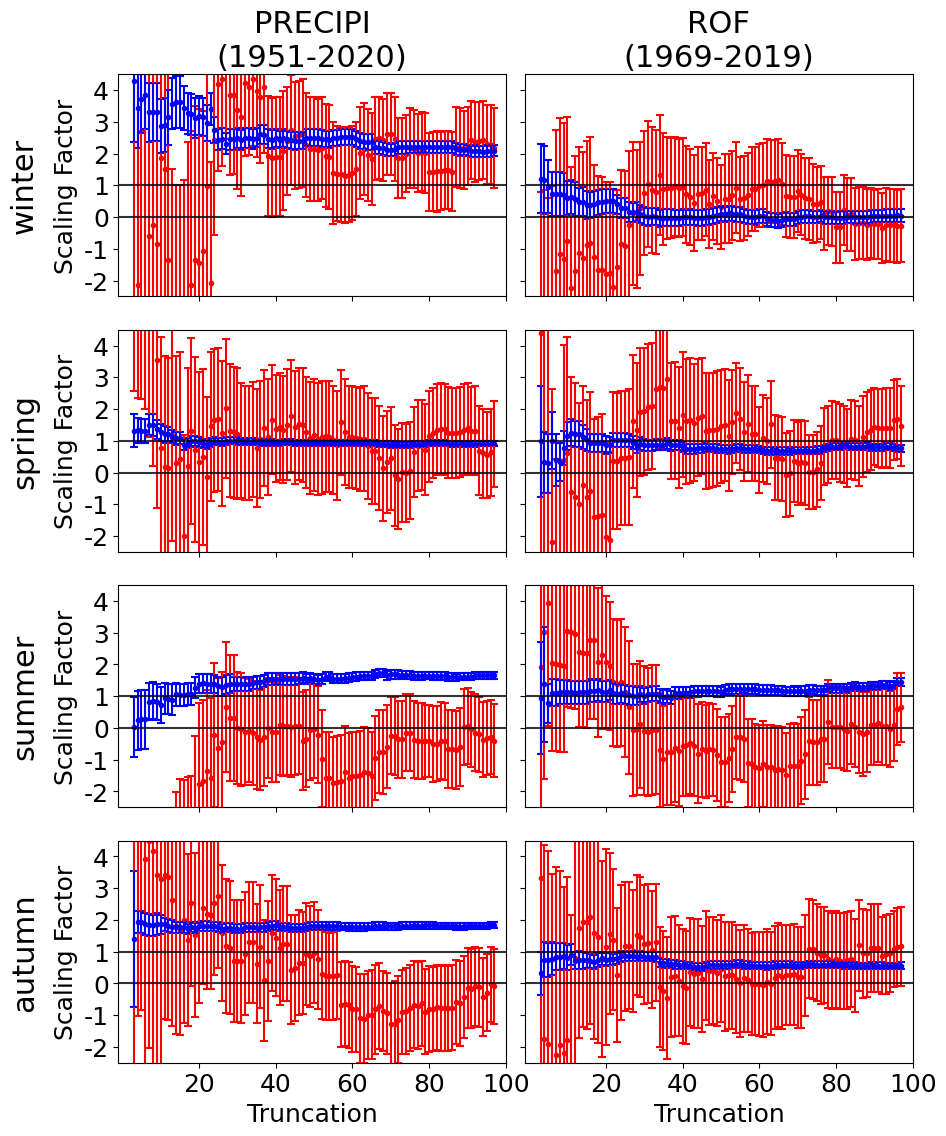

In [5]:
'''

'''

def plot_obs_OF_results(ax,i,j,var,season,font):

    df = result_df.query('variable==\''+var+'\' and season==\''+season+'\'').sort_values('Truncation')

    x_vals = df['Truncation']

    ax.scatter(x_vals,df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(x_vals,df['ant_upper'],color='red',marker='_')
    ax.scatter(x_vals,df['ant_lower'],color='red',marker='_')
    ax.vlines(x_vals,df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(x_vals,df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(x_vals,df['nat_upper'],color='blue',marker='_')
    ax.scatter(x_vals,df['nat_lower'],color='blue',marker='_')
    ax.vlines(x_vals,df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
    ax.set_ylim(-2.5,4.5)
    
    if j == 0:
        font['size'] = 18
        ax.set_ylabel('Scaling Factor',fontdict=font)
        ax.set_yticks([-2,-1,0,1,2,3,4])
        ax.set_yticklabels(['-2','-1','0','1','2','3','4'],fontdict=font)
        font['size'] = 22
        ax.text(-.28,.5,season,transform=ax.transAxes,fontdict=font,rotation='vertical',va='center')
        
    if i == 0:
        font['size'] = 22
        ax.set_title(var + '\n' + '(' + time_windows[var][0] + '-' + time_windows[var][1] + ')',fontdict=font)
        
    if i == 0 and j == 2:
        ax.legend(fontsize=18,loc='upper right', markerscale=2.5)

    if i == 3:
        font['size'] = 18
        ax.set_xlabel('Truncation',fontdict=font)
        font['size'] = 22

    font['size'] = 18
    ax.set_xlim(-1,100)
    ax.set_xticks([20*i for i in range(1,6)])
    ax.set_xticklabels([str(20*j) if i == 3 else '' for j in range(1,6)],fontdict=font)
    font['size'] = 22


fig,axs = plt.subplots(4, 2, figsize=(10,12), sharey=True)#,constrained_layout=True)

for i,season in enumerate(['winter','spring','summer','autumn']):

    for j,var in enumerate(['PRECIPI','ROF']):
        
        plot_obs_OF_results(axs[i][j],i,j,var,season,font)

plt.tight_layout(pad=3)
plt.subplots_adjust(hspace=0.15,wspace=0.05)

fig.patch.set_alpha(1)

fig.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_OF_raw_d4PDF.png',dpi=300)

